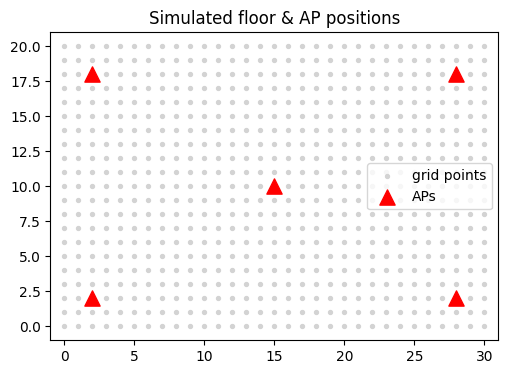

k-NN fingerprinting RMSE (m): 3.3299029285548727
RSSI trilateration RMSE (m): 4.536354077578102


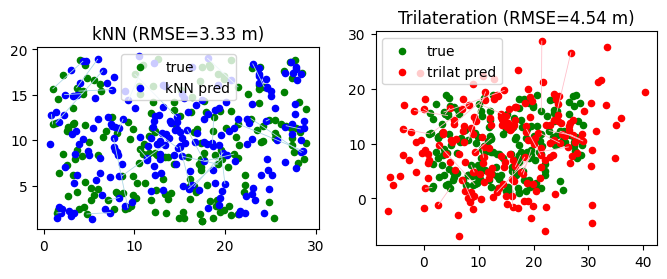

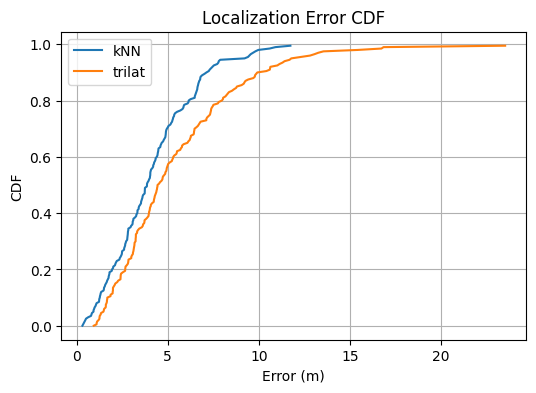

In [1]:
# wifi_localization_sim.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from scipy.optimize import least_squares
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# ===== Simulation parameters =====
AREA_W, AREA_H = 30.0, 20.0            # meters (floor plan)
GRID_RES = 1.0                         # meters between grid points
AP_POS = np.array([[2,2],[28,2],[2,18],[28,18],[15,10]])  # AP coordinates (x,y)
PATH_LOSS_EXP = 2.7                    # indoor path-loss exponent (2-4 typical)
RSSI_AT_1M = -40.0                     # dBm at 1 meter (Tx power reference)
SHADOW_STD = 3.5                       # shadowing std dev (dB)
MEASUREMENT_NOISE_STD = 2.0            # additional measurement noise (dB)

# ===== generate grid points (radiomap) =====
xs = np.arange(0, AREA_W + 1e-6, GRID_RES)
ys = np.arange(0, AREA_H + 1e-6, GRID_RES)
xx, yy = np.meshgrid(xs, ys)
grid = np.vstack([xx.ravel(), yy.ravel()]).T
n_grid = grid.shape[0]

def rssi_from_dist(d):
    # Log-distance path loss: RSSI(d) = RSSI_1m - 10 * n * log10(d)
    # handle d<1
    d = np.maximum(d, 0.001)
    return RSSI_AT_1M - 10.0 * PATH_LOSS_EXP * np.log10(d)

# ===== create radiomap: for every grid point, compute RSSI vector (with shadowing) =====
def make_rssi_map(add_shadow=True):
    rssi_map = np.zeros((n_grid, AP_POS.shape[0]))
    for i, p in enumerate(grid):
        dists = np.linalg.norm(AP_POS - p, axis=1)
        rssi = rssi_from_dist(dists)
        if add_shadow:
            rssi += np.random.normal(0, SHADOW_STD, size=rssi.shape)
        rssi_map[i,:] = rssi
    return rssi_map

radiomap = make_rssi_map(add_shadow=True)

# visualize APs and grid
plt.figure(figsize=(6,4))
plt.scatter(grid[:,0], grid[:,1], s=8, c='lightgray', label='grid points')
plt.scatter(AP_POS[:,0], AP_POS[:,1], c='red', marker='^', s=120, label='APs')
plt.legend()
plt.title("Simulated floor & AP positions")
plt.xlim(-1, AREA_W+1)
plt.ylim(-1, AREA_H+1)
plt.gca().set_aspect('equal', 'box')
plt.show()

# ===== simulate test trajectory: some random locations (true positions) and measured RSSI =====
n_test = 200
test_pos = np.column_stack((np.random.uniform(1, AREA_W-1, n_test),
                            np.random.uniform(1, AREA_H-1, n_test)))

def measure_rssi_at(pos, add_noise=True):
    d = np.linalg.norm(AP_POS - pos, axis=1)
    rssi = rssi_from_dist(d)
    if add_noise:
        rssi += np.random.normal(0, SHADOW_STD, size=rssi.shape)   # shadowing
        rssi += np.random.normal(0, MEASUREMENT_NOISE_STD, size=rssi.shape)  # meas noise
    return rssi

test_rssi = np.array([measure_rssi_at(p) for p in test_pos])

# ===== Method A: k-NN fingerprinting (regression for XY) =====
# use radiomap without per-measure noise for database (or use many samples per grid cell)
db_rssi = radiomap.copy()
db_pos = grid.copy()

# Train KNN regressor: map RSSI -> position (x,y)
knn = KNeighborsRegressor(n_neighbors=3, weights='distance', metric='euclidean')
knn.fit(db_rssi, db_pos)

pred_knn = knn.predict(test_rssi)
rmse_knn = np.sqrt(mean_squared_error(test_pos, pred_knn))
print("k-NN fingerprinting RMSE (m):", rmse_knn)

# ===== Method B: RSSI trilateration via distance estimation + least-squares multilateration =====
# Estimate distance from RSSI using inverse of log-distance:
def rssi_to_distance(rssi):
    # d = 10 ^ ((RSSI_1M - RSSI) / (10 * n))
    return 10 ** ((RSSI_AT_1M - rssi) / (10.0 * PATH_LOSS_EXP))

def multilateration_from_rssis(rssi_vec, initial_guess=None):
    # convert rssi->distances
    dists = rssi_to_distance(rssi_vec)
    # solve for position x that minimizes sum((||x - ap_i|| - d_i)^2)
    if initial_guess is None:
        initial_guess = np.mean(AP_POS, axis=0)
    def residuals(x):
        return np.linalg.norm(AP_POS - x, axis=1) - dists
    res = least_squares(residuals, x0=initial_guess, method='lm')
    return res.x

pred_trilat = np.array([multilateration_from_rssis(r) for r in test_rssi])
rmse_trilat = np.sqrt(mean_squared_error(test_pos, pred_trilat))
print("RSSI trilateration RMSE (m):", rmse_trilat)

# ===== visualize errors =====
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.scatter(test_pos[:,0], test_pos[:,1], c='green', s=20, label='true')
plt.scatter(pred_knn[:,0], pred_knn[:,1], c='blue', s=20, label='kNN pred')
for t,p in zip(test_pos[:30], pred_knn[:30]):
    plt.plot([t[0], p[0]], [t[1], p[1]], color='lightblue', linewidth=0.6)
plt.title(f"kNN (RMSE={rmse_knn:.2f} m)")
plt.legend()
plt.gca().set_aspect('equal','box')

plt.subplot(1,2,2)
plt.scatter(test_pos[:,0], test_pos[:,1], c='green', s=20, label='true')
plt.scatter(pred_trilat[:,0], pred_trilat[:,1], c='red', s=20, label='trilat pred')
for t,p in zip(test_pos[:30], pred_trilat[:30]):
    plt.plot([t[0], p[0]], [t[1], p[1]], color='pink', linewidth=0.6)
plt.title(f"Trilateration (RMSE={rmse_trilat:.2f} m)")
plt.legend()
plt.gca().set_aspect('equal','box')
plt.show()

# ===== output CDF of errors =====
err_knn = np.linalg.norm(pred_knn - test_pos, axis=1)
err_trilat = np.linalg.norm(pred_trilat - test_pos, axis=1)

plt.figure(figsize=(6,4))
for err, label in [(err_knn, 'kNN'), (err_trilat,'trilat')]:
    sorted_e = np.sort(err)
    cdf = np.arange(len(sorted_e)) / float(len(sorted_e))
    plt.plot(sorted_e, cdf, label=label)
plt.xlabel('Error (m)')
plt.ylabel('CDF')
plt.title('Localization Error CDF')
plt.legend()
plt.grid(True)
plt.show()
